In [1]:
import torch
import equiv_dens.utils.base as utils
import equiv_dens.utils.orbitals as orbitals
from equiv_dens.utils.spherical_harmonics import spherical_harmonics
import equiv_dens.utils.spherical_harmonics_deriv as sph_deriv
import numpy as np
from torchviz import make_dot
%load_ext autoreload
%autoreload 2

loading config file None


In [28]:
# Setting up distances, directions and coeffs as variables
coords = torch.randn(1, 3, 3)
coords.requires_grad = True
print('coords', coords)
max_L = 5
d, u = utils.calculate_distances_and_directions(coords, center=torch.zeros(1, 1, 3))
s = spherical_harmonics(max_L, u)
print('s requires grad', [ss.requires_grad for ss in s])
for L in range(len(s)):
    zeros = torch.zeros_like(s[L])
    s[L] = torch.where(torch.isnan(s[L]), zeros, s[L])  # making sure there are no nans to avoid NaNs
print('dist', d)
print('unit', u)
scales = [torch.randn(1, 1, 1, 1) for L in range(max_L + 1)]
widths = [torch.randn(1, 1, 1, 1)**2 for L in range(max_L + 1)]
coeffs = [torch.randn(1, 1, 2 * L + 1, 1) for L in range(max_L + 1)]
print([ss.shape for ss in s])
print('scales', scales)
print('widths', widths)
print('coeffs', coeffs)

coords tensor([[[-2.7143,  0.7987, -1.0811],
         [-0.8129, -1.6944,  0.7480],
         [ 1.0156,  0.4422, -0.6096]]], requires_grad=True)
s requires grad [False, True, True, True, True, True]
dist tensor([[[3.0289],
         [2.0227],
         [1.2643]]], grad_fn=<LinalgVectorNormBackward0>)
unit tensor([[[ 0.8961, -0.2637,  0.3569],
         [ 0.4019,  0.8377, -0.3698],
         [-0.8032, -0.3498,  0.4822]]], grad_fn=<DivBackward0>)
[torch.Size([1, 3, 1]), torch.Size([1, 3, 3]), torch.Size([1, 3, 5]), torch.Size([1, 3, 7]), torch.Size([1, 3, 9]), torch.Size([1, 3, 11])]
scales [tensor([[[[-0.0854]]]]), tensor([[[[-0.4628]]]]), tensor([[[[-0.6506]]]]), tensor([[[[-0.8809]]]]), tensor([[[[1.5761]]]]), tensor([[[[-0.9746]]]])]
widths [tensor([[[[0.0341]]]]), tensor([[[[0.2952]]]]), tensor([[[[0.0918]]]]), tensor([[[[0.4067]]]]), tensor([[[[0.0770]]]]), tensor([[[[1.8419]]]])]
coeffs [tensor([[[[-1.1143]]]]), tensor([[[[-0.3535],
          [-0.5896],
          [ 0.5395]]]]), tensor([

In [32]:
# basic gto calculation
gto = 0

for L in range(max_L + 1):
    scale = scales[L]
    width = widths[L]
    coeff = coeffs[L]
    sph = s[L].unsqueeze(-1) * coeff
    print('sph shape', sph.shape)
    # if L == 1:
        # print('sL shape', s[L].shape)
        # print('sph grad', torch.autograd.grad(sph[0, 0, 0, 0], coords))
    rbf = orbitals.gaussian_rbf(d.unsqueeze(-1), width, scale, L)
    gto += torch.sum(rbf * sph, dim=(-2, -1))
print(gto)

sph shape torch.Size([1, 3, 1, 1])
sph shape torch.Size([1, 3, 3, 1])
sph shape torch.Size([1, 3, 5, 1])
sph shape torch.Size([1, 3, 7, 1])
sph shape torch.Size([1, 3, 9, 1])
sph shape torch.Size([1, 3, 11, 1])
tensor([[-18.7608, -87.0645,  27.5518]], grad_fn=<AddBackward0>)


In [33]:
# testing autograd calculation for gto
grad = 0
for i in range(3):
    grad += torch.autograd.grad(gto.squeeze()[i], coords, retain_graph=True)[0]
print(grad)

tensor([[[ 16.5202, -25.0406, -77.2505],
         [ 80.7498,  40.8833, -34.5165],
         [ 90.8503, -45.5722, -33.9325]]])


In [25]:
# main cell for calculating GTO gradient, comparing autodiff to explicit gradient
print('coords requires grad', coords.requires_grad)
print('u requires grad', u.requires_grad)
print('s requres grad', s[0].requires_grad)
print('coords', coords)
print('u', u)
gto = 0
gto_grad = 0
s_deriv = sph_deriv.spherical_harmonics_deriv(max_L, u)
dcoords = torch.eye(3).unsqueeze(0).unsqueeze(0)
print(dcoords.shape)
for L in range(max_L + 1):
    scale = scales[L]
    width = widths[L]
    coeff = coeffs[L]
    sph = s[L].unsqueeze(-1) * coeff
    print('L', L)
    print('coeff shape', coeff.shape)
    print('s[L] shape', s[L].shape)
    print('s[l] deriv shape', s_deriv[L].shape)
    print('sph', sph)
    sph_autograd = 0
    du = 0
    if L != 0:
        for i in range(sph.squeeze().shape[0]):
            for j in range(sph.squeeze().shape[1]):
                sph_autograd += torch.autograd.grad(sph.squeeze()[i, j], coords, retain_graph=True)[0]
                du += torch.autograd.grad(sph.squeeze()[i, j], u, retain_graph=True)[0]
                # print(sph_autograd)
    # print('sph du autograd', du)
    if L != 1:
        sph_grad = (s_deriv[L].unsqueeze(-1) * coeff.unsqueeze(0)).sum((-1, -2))
    else:
        sph_grad = (s_deriv[L].unsqueeze(-1) * coeff[..., [2, 0, 1], :]).sum(-1)
    # print('sph du deriv', sph_grad)
    # print('sph autograd', sph_autograd)
    sph_grad_c = sph_grad.unsqueeze(-2) * -(dcoords/d.unsqueeze(-1) -
                 (coords.unsqueeze(-2) * coords.unsqueeze(-1)/d.unsqueeze(-1)**3))
    sph_grad_c = sph_grad_c.sum(-1)
    # print('sph u and c ratio', sph_autograd / sph_grad)
    rbf = orbitals.gaussian_rbf(d.unsqueeze(-1), width, scale, L)
    rbf_autograd = 0
    for i in range(3):
        rbf_autograd += torch.autograd.grad(rbf.squeeze()[i], coords, retain_graph=True)[0]
    # print('rbf autograd', rbf_autograd)
    rbf_grad = orbitals.gaussian_rbf_deriv(d.unsqueeze(-1), width, scale, L).squeeze(-1) * coords / d
    # print('rbf_deriv', rbf_grad)
    print('coords.shape', coords.shape)
    gto_l = torch.sum(rbf * sph, dim=(-2, -1)) 
    gto_autograd = 0
    for i in range(3):
        gto_autograd += torch.autograd.grad(gto_l.squeeze()[i], coords, retain_graph=True)[0]
    print('rbf shape', rbf.shape)
    print('rbf grad shape', rbf_grad.shape)
    print('rbf grad unsqueeze shape', rbf_grad.unsqueeze(-2).shape)
    print('sph shape', sph.shape)
    print('sph deriv unsqueeze coords', sph_grad_c.unsqueeze(-1).shape) 
    print('rbf_grad unsqueeze * sph', (rbf_grad.unsqueeze(-2) * sph).shape)
    print('rbf* sph_grad unsqueeze ', (rbf * sph_grad_c.unsqueeze(-1)).shape)
    gto_deriv = torch.sum(rbf_grad.unsqueeze(-2) * sph, -2) + rbf.squeeze(-1) * sph_grad_c
    print('gto autograd', gto_autograd)
    print('gto deriv', gto_deriv)
    gto += gto_l 
    gto_grad += gto_deriv

# grad = torch.autograd.grad(gto[0,1], coords, retain_graph=True)
# print(grad)
grad = 0
for i in range(3):
    grad += torch.autograd.grad(gto.squeeze()[i], coords, retain_graph=True)[0]
print('gto', gto)
print('total gto coords grad', grad)
print('explicit gto coords grad', gto_grad)

coords requires grad True
u requires grad True
s requres grad False
coords tensor([[[ 0.7963, -1.1634,  1.4412],
         [ 0.5784, -0.1977,  0.6028],
         [-1.1879,  0.3099,  2.3044]]], requires_grad=True)
u tensor([[[-0.3950,  0.5770, -0.7148],
         [-0.6737,  0.2303, -0.7022],
         [ 0.4550, -0.1187, -0.8826]]], grad_fn=<DivBackward0>)
torch.Size([1, 1, 3, 3])
L 0
coeff shape torch.Size([1, 1, 1, 1])
s[L] shape torch.Size([1, 3, 1])
s[l] deriv shape torch.Size([1, 3, 1])
sph tensor([[[[-0.6290]],

         [[-0.6290]],

         [[-0.6290]]]])
coords.shape torch.Size([1, 3, 3])
rbf shape torch.Size([1, 3, 1, 1])
rbf grad shape torch.Size([1, 3, 3])
rbf grad unsqueeze shape torch.Size([1, 3, 1, 3])
sph shape torch.Size([1, 3, 1, 1])
sph deriv unsqueeze coords torch.Size([1, 3, 3, 1])
rbf_grad unsqueeze * sph torch.Size([1, 3, 1, 3])
rbf* sph_grad unsqueeze  torch.Size([1, 3, 3, 1])
gto autograd tensor([[[ 0.0129, -0.0188,  0.0233],
         [ 0.0119, -0.0041,  0.0124],
  

In [7]:
# calculating gradient for u, the normalized interatomic direction
du = 0.0
for i in range(u.squeeze().shape[0]):
    for j in range(u.squeeze().shape[1]):
        du += torch.autograd.grad(u.squeeze()[i, j], coords, retain_graph=True)[0]

dcoords = torch.eye(3).unsqueeze(0).unsqueeze(-1)
dcoords = dcoords.expand((-1 ,-1 ,-1, 3))

u_deriv = -(1 / d - (coords * torch.sum(coords, dim=(-1), keepdim=True) / d**3))
print('du', du)
print('u_deriv', u_deriv)

du tensor([[[-0.0257, -0.4613, -0.3720],
         [-0.9595, -0.0624, -1.4628],
         [-0.4800, -0.1804, -0.5118]]])
u_deriv tensor([[[-0.0257, -0.4613, -0.3720],
         [-0.9595, -0.0624, -1.4628],
         [-0.4800, -0.1804, -0.5118]]], grad_fn=<NegBackward0>)


In [8]:
# combining gradient of degree 1 gto with the derivative of u via chain rule
sph_grad = (s_deriv[1].unsqueeze(-1) * coeffs[1][..., [2, 0, 1], :]).sum(-1)
# sph_grad = (s_deriv[2].unsqueeze(-1) * coeffs[2]).sum((-1, -2))
print('sph grad shape', sph_grad.shape)
dcoords = torch.eye(3).unsqueeze(0).unsqueeze(0)
# dcoords = dcoords.expand((-1 , 3 ,-1, -1))
u_deriv = -(dcoords/d.unsqueeze(-1) - (coords.unsqueeze(-2) * coords.unsqueeze(-1)/d.unsqueeze(-1)**3))
print('u_deriv shape', u_deriv.shape)
print('u_deriv', (sph_grad.unsqueeze(-2) * u_deriv).sum(-1))

sph grad shape torch.Size([1, 3, 3])
u_deriv shape torch.Size([1, 3, 3, 3])
u_deriv tensor([[[ 0.0796,  0.4813, -0.1523],
         [-2.2177,  0.4373, -0.4140],
         [-0.6079, -0.0900, -0.0701]]], grad_fn=<SumBackward1>)


In [10]:
# further tests for calculating the derivative of the degree 1 GTO with plotting of gradient graph
coords2 = torch.tensor(coords)
coords2.requires_grad = True
coeffs1 = torch.tensor(coeffs[1])
class Direction(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.dummy = torch.nn.Parameter(torch.ones((1, 3, 3)))

    def forward(self, Ri):
        Ri = Ri * self.dummy
        Rj = torch.zeros_like(Ri)
        rij = Rj - Ri  # displacement vectors
        dij = torch.norm(rij, dim=-1, keepdim=True)  # distances
        uij = rij / dij  # unit displacement vectors
        return uij

class L1(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.dummy = torch.nn.Parameter(torch.ones((1, 3, 3)))

    def forward(self, u):
        u = u * self.dummy
        print('u', u)
        return np.sqrt(3) * u[..., [1, 2, 0]] 

class SphCoeffs(torch.nn.Module):
    def __init__(self, coeffs):
        super().__init__()
        self.coeffs = torch.nn.Parameter(coeffs)

    def forward(self, s):
        return s.unsqueeze(-1) * self.coeffs

l1 = L1()
dir = Direction()
sphcoeffs = SphCoeffs(coeffs1)
model = torch.nn.Sequential(dir, l1, sphcoeffs)

print('coords', coords2)

sph_l1 = model(coords2)
# make_dot(sph_l1.mean(), params=dict(model.named_parameters()))
print("l1", sph_l1)
l = sph_l1.sum()
l.backward()
print('coords_grad', coords2.grad)
print('l1 dummy', l1.dummy.grad)
print('dir dummy', dir.dummy.grad)

coords tensor([[[ 2.4083, -0.3240,  0.2356],
         [-0.1813, -0.7756,  0.1520],
         [-0.2597,  2.1570, -0.5168]]], requires_grad=True)
u tensor([[[-0.9864,  0.1327, -0.0965],
         [ 0.2236,  0.9565, -0.1875],
         [ 0.1163, -0.9659,  0.2314]]], grad_fn=<MulBackward0>)
l1 tensor([[[[-0.1871],
          [-0.0523],
          [-1.5305]],

         [[-1.3485],
          [-0.1017],
          [ 0.3469]],

         [[ 1.3617],
          [ 0.1256],
          [ 0.1804]]]], grad_fn=<MulBackward0>)
coords_grad tensor([[[ 0.0796,  0.4813, -0.1523],
         [-2.2177,  0.4373, -0.4140],
         [-0.6079, -0.0900, -0.0701]]])
l1 dummy tensor([[[-1.5305, -0.1871, -0.0523],
         [ 0.3469, -1.3485, -0.1017],
         [ 0.1804,  1.3617,  0.1256]]])
dir dummy tensor([[[ 0.1918, -0.1559, -0.0359],
         [ 0.4021, -0.3392, -0.0629],
         [ 0.1579, -0.1941,  0.0362]]])


/tmp/ipykernel_1347811/3768104441.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  coords2 = torch.tensor(coords)
/tmp/ipykernel_1347811/3768104441.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  coeffs1 = torch.tensor(coeffs[1])


u grad tensor([[[-1.8598,  0.1849, -2.6512],
         [-0.7965, -2.1502,  2.5120],
         [ 1.4414,  2.0610, -1.4502]]])
d grad tensor([[[ 0.8663],
         [-3.3368],
         [-0.9666]]])
c_pow2_sum grad tensor([[[ 0.1774],
         [-2.0576],
         [-0.2164]]])
c_pow2 grad tensor([[[ 0.1774,  0.1774,  0.1774],
         [-2.0576, -2.0576, -2.0576],
         [-0.2164, -0.2164, -0.2164]]])
one side? tensor([[[ 0.8545, -0.1150,  0.0836],
         [ 0.7461,  3.1915, -0.6255],
         [ 0.1124, -0.9337,  0.2237]]], grad_fn=<MulBackward0>)
coords grad tensor([[[ 0.0928, -0.0392, -1.0023],
         [-0.2362,  0.5398,  2.4725],
         [ 0.7578, -0.0108, -0.4257]]])
coords tensor([[[ 2.4083, -0.3240,  0.2356],
         [-0.1813, -0.7756,  0.1520],
         [-0.2597,  2.1570, -0.5168]]], requires_grad=True)
final grad? tensor([[[ 0.0928, -0.0392, -1.0023],
         [-0.2362,  0.5398,  2.4725],
         [ 0.7578, -0.0108, -0.4257]]], grad_fn=<AddBackward0>)


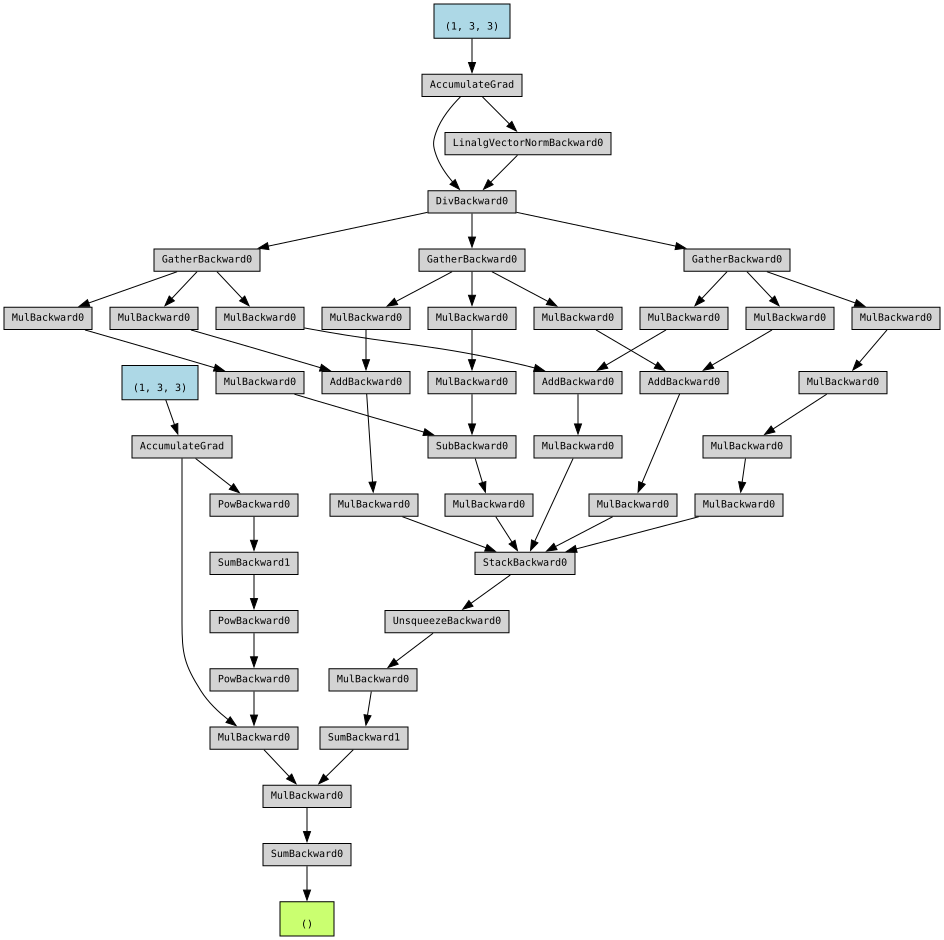

In [19]:
# calculating gradient graph for degree 1 gto detailed steps version with initial gradien from spherical harmonics
coords2 = coords.clone().detach()
coords2.requires_grad = True
coeffs1 = coeffs[2].clone().detach()
c_pow2 = coords2**2
c_pow2.retain_grad()
c_pow2_sum = c_pow2.sum(-1, keepdim=True)
c_pow2_sum.retain_grad()
d = c_pow2_sum**(0.5)
d.retain_grad()
u2 = coords2 * d**(-1)  # unit displacement vectors
u2.retain_grad()
l = (u2 * sph_grad).sum()
# l = u2.sum()
l.backward(retain_graph=True)
print('u grad', u2.grad)
print('d grad', d.grad)
print('c_pow2_sum grad', c_pow2_sum.grad)
print('c_pow2 grad', c_pow2.grad)
print('one side?', 2 * coords2 * c_pow2.grad)
print('coords grad', coords2.grad)
print('coords', coords)
print('final grad?', 2 * coords2 * c_pow2.grad + sph_grad/d)
make_dot(l)

In [13]:
# explicitly calculating gradient for degree 1 GTO, ensuring correct dimensions and broadcasting
s_deriv = sph_deriv.spherical_harmonics_deriv(2, u)

sph_grad = (s_deriv[2].unsqueeze(-1) * coeffs[2]).sum((-1,-2))
print('sph_grad.shape', sph_grad.shape)

dudr = -(1 / d - (coords * torch.sum(coords, dim=(-1), keepdim=True) / d**3)) 
dudd = (coords / -d**2)
dddp = 1/(2 *  torch.sqrt(torch.sum(coords**2, -1, keepdim=True)))
dpds = 2*coords
sph_grad_c = sph_grad * dudr
print('s grad', s_deriv[1])
print('sph_grad', sph_grad)
print('u grad r', dudr)
print('u grad d', (sph_grad*dudd).sum(-1, keepdim=True))
print('d grad sqrt', (sph_grad*dudd*dddp).sum(-1, keepdim=True))
print('sqrt grad sum', dpds*(sph_grad*dddp*dudd).sum(-1, keepdim=True))
print('sqrt grad sum', dpds*(sph_grad*dddp*dudd).sum(-1, keepdim=True))
print('sum up', sph_grad*1/d + dpds*(sph_grad*dddp*dudd).sum(-1, keepdim=True))
# print('second part', (coords * torch.sum(coords, dim=(-1), keepdim=True) / d**3))
# print('sph_grad_c', sph_grad_c)

sph_grad.shape torch.Size([1, 3, 3])
s grad tensor([[[1.7321, 1.7321, 1.7321],
         [1.7321, 1.7321, 1.7321],
         [1.7321, 1.7321, 1.7321]]])
sph_grad tensor([[[-1.8598,  0.1849, -2.6512],
         [-0.7965, -2.1502,  2.5120],
         [ 1.4414,  2.0610, -1.4502]]], grad_fn=<SumBackward1>)
u grad r tensor([[[-0.0257, -0.4613, -0.3720],
         [-0.9595, -0.0624, -1.4628],
         [-0.4800, -0.1804, -0.5118]]], grad_fn=<NegBackward0>)
u grad d tensor([[[ 0.8663],
         [-3.3368],
         [-0.9666]]], grad_fn=<SumBackward1>)
d grad sqrt tensor([[[ 0.1774],
         [-2.0576],
         [-0.2164]]], grad_fn=<SumBackward1>)
sqrt grad sum tensor([[[ 0.8545, -0.1150,  0.0836],
         [ 0.7461,  3.1915, -0.6255],
         [ 0.1124, -0.9337,  0.2237]]], grad_fn=<MulBackward0>)
sqrt grad sum tensor([[[ 0.8545, -0.1150,  0.0836],
         [ 0.7461,  3.1915, -0.6255],
         [ 0.1124, -0.9337,  0.2237]]], grad_fn=<MulBackward0>)
sum up tensor([[[ 0.0928, -0.0392, -1.0023],
     